# Modélisation et evaluation du risque de crédit

**Objectif de ce notebook :**
À partir des données nettoyées, nous allons entraîner et comparer des algorithmes de Machine Learning pour prédire le risque de défaut de paiement de nos clients. 

In [11]:
#!pip install scikit-learn joblib

## Initialisation des données traitées précedemment

### 1. Chargement et correction métier (`DAYS_EMPLOYED`)

Lors de l'exploration des données, nous avons remarqué une anomalie majeure : la valeur `365243` (soit 1000 ans) dans la colonne des jours travaillés. Cette valeur correspond en réalité aux clients **retraités**. 
Pour ne pas fausser les mathématiques de notre algorithme, nous créons une colonne binaire pour identifier ces retraités, et nous remplaçons l'anomalie par `0`.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du dataset
chemin_fichier = '../data/dataset/application_train_cleaned.csv'
df = pd.read_csv(chemin_fichier)

#Remplacement anomalie
df['ANOMALIE_DAYS_EMPLOYED'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace({365243: 0})

print(f"Taille du dataset : {df.shape}")

Taille du dataset : (307511, 217)


C:\Users\ameti\AppData\Local\Temp\ipykernel_18796\2292945047.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['ANOMALIE_DAYS_EMPLOYED'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)


## Sepration des données pour l'entrainement et les tests

In [13]:
y = df['TARGET']
X = df.drop(columns=["TARGET"])

# Séparation des données (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Tailles des splits
print(f"Taille de X_train : {X_train.shape}")
print(f"Taille de X_test  : {X_test.shape}")

Taille de X_train : (246008, 216)
Taille de X_test  : (61503, 216)


Stratify a été utiliser pour garantir que dans nos jeux de données on n'ait pas que des bons payers ou que des mauvais avec le hasard, là on a une garanti d'avoir un ratio 92/8.

### 3. Mise à l'échelle (Standardisation)

Les algorithmes comme la Régression Logistique sont sensibles aux différences d'échelles (ex: l'âge varie de 20 à 70, mais le salaire varie en centaines de milliers). 
Nous utilisons le `StandardScaler` pour ramener toutes nos variables sur une même échelle (moyenne = 0, écart-type = 1). 
*Attention : Le scaler est "appris" (fit) uniquement sur le Train pour éviter toute fuite de données (Data Leakage) vers le Test.*

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modèle 1 : Régression logistique

La Régression Logistique est très prisée en banque car elle est totalement transparente et explicable. 
Notre jeu de données est très déséquilibré (seulement 8% de mauvais payeurs). Si nous ne faisons rien, le modèle prédira toujours "Bon payeur". 
L'argument `class_weight='balanced'` pénalise mathématiquement le modèle beaucoup plus lourdement s'il se trompe sur un mauvais payeur.

In [15]:

modele_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

modele_lr.fit(X_train_scaled, y_train)

y_pred = modele_lr.predict(X_test_scaled)


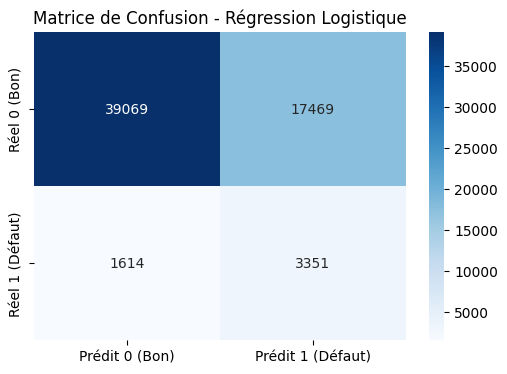

              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



In [16]:
# 1. Matrice de confusion visuelle
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
# On utilise Seaborn pour faire une belle carte de chaleur (heatmap)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prédit 0 (Bon)', 'Prédit 1 (Défaut)'], 
            yticklabels=['Réel 0 (Bon)', 'Réel 1 (Défaut)'])
plt.title('Matrice de Confusion - Régression Logistique')
plt.show()

# Rapport de classification 
print(classification_report(y_test, y_pred))

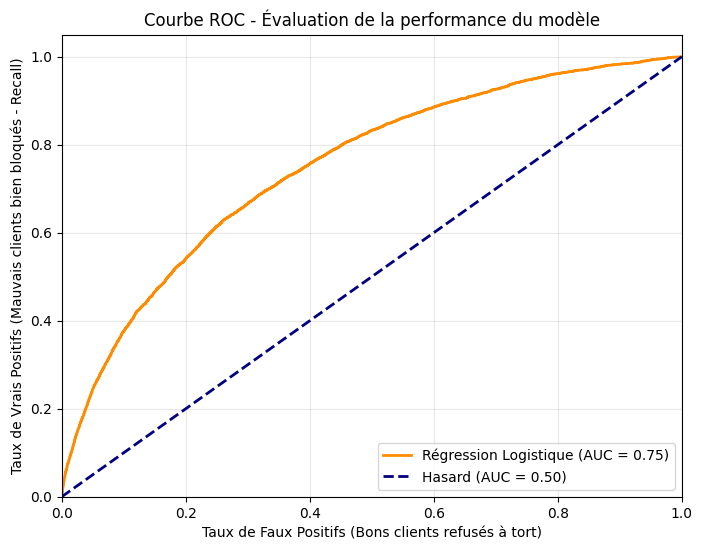

In [17]:
y_prob = modele_lr.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
score_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# La courbe de notre modèle
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Régression Logistique (AUC = {score_auc:.2f})')

# La ligne diagonale (hasard pur)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Hasard (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (Bons clients refusés à tort)')
plt.ylabel('Taux de Vrais Positifs (Mauvais clients bien bloqués - Recall)')
plt.title('Courbe ROC - Évaluation de la performance du modèle')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.show()

## RandomForest

In [18]:
modele_rf = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)

#Entraînement
modele_rf.fit(X_train_scaled, y_train)

#Prédictions
y_pred_rf = modele_rf.predict(X_test_scaled)
y_prob_rf = modele_rf.predict_proba(X_test_scaled)[:, 1]

#Évaluation
print("\n=== Rapport de Classification (Random Forest) ===")
print(classification_report(y_test, y_pred_rf))

#Calcul de l'AUC
from sklearn.metrics import roc_curve, auc
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
score_auc_rf = auc(fpr_rf, tpr_rf)

print(f"\nScore AUC du Random Forest : {score_auc_rf:.3f}")


=== Rapport de Classification (Random Forest) ===
              precision    recall  f1-score   support

           0       0.96      0.73      0.83     56538
           1       0.16      0.61      0.26      4965

    accuracy                           0.72     61503
   macro avg       0.56      0.67      0.54     61503
weighted avg       0.89      0.72      0.78     61503


Score AUC du Random Forest : 0.732


### Conclusion du benchmark

Contre toute attente, le modèle le plus complexe n'est pas le meilleur ici :
* **Régression Logistique :** AUC de 0.75 et Recall de 67% sur les fraudeurs.
* **Random Forest :** AUC de 0.73 et Recall de 61% sur les fraudeurs.

Le *Random Forest* souffre de la forte présence de colonnes binaires (issues du One-Hot Encoding). 
Nous allons donc conserver la **Régression Logistique** car elle identifie mieux le risque, s'entraîne plus vite, et nous permet d'expliquer au client pourquoi son prêt est refusé.

## Données qui influent le plus

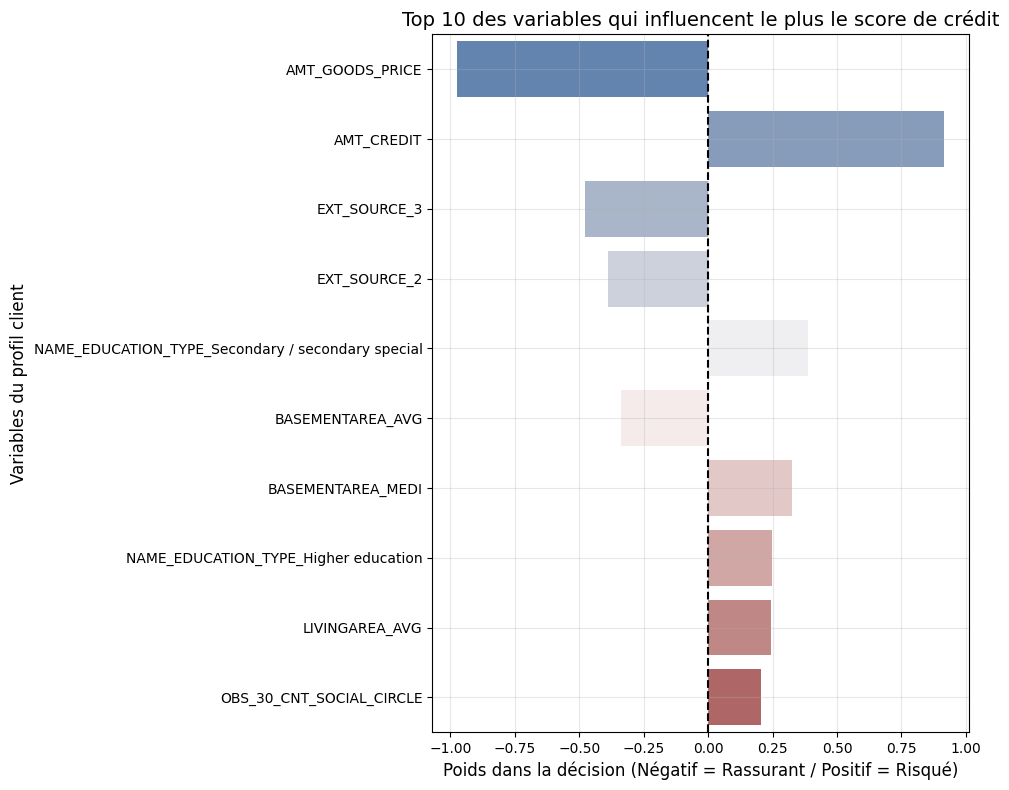

In [19]:
noms_variables = X.columns
poids = modele_lr.coef_[0]

df_importance = pd.DataFrame({
    'Variable': noms_variables,
    'Coefficient': poids
})

df_importance['Impact_Absolu'] = df_importance['Coefficient'].abs()
df_importance = df_importance.sort_values(by='Impact_Absolu', ascending=False)

top_20 = df_importance.head(10)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_20, x='Coefficient', y='Variable', hue='Variable', palette='vlag', legend=False)

plt.title('Top 10 des variables qui influencent le plus le score de crédit', fontsize=14)
plt.xlabel('Poids dans la décision (Négatif = Rassurant / Positif = Risqué)', fontsize=12)
plt.ylabel('Variables du profil client', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--') # Ligne du zéro
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

**Analyse des Coefficients :**
* **Les facteurs rassurants (vers la gauche) :** Le modèle a compris que le profil "Retraité" (`Pensioner`) ainsi que l'achat de biens de forte valeur (`AMT_GOODS_PRICE`) diminuent fortement le risque de défaut.
* **Les facteurs de risque (vers la droite) :** À l'inverse, un montant de crédit très élevé (`AMT_CREDIT`) ou le fait d'avoir été accompagné par un agent extérieur (`NAME_TYPE_SUITE_Spouse, partner`) augmentent le score de risque.

## Sauvegarde du modèle 

In [20]:
import joblib

#Sauvegarde du modèle
joblib.dump(modele_lr, '../data/modele_credit_scoring.joblib')

# 2. Sauvegarde du filtre
joblib.dump(scaler, '../data/scaler_credit_scoring.joblib')

X_test.head(50).to_csv('../data/echantillon_clients.csv', index=True)
print("Sauvegarde effectué")

Sauvegarde effectué
